This notebook will contain all the different ATT estimates across different versions of the basefile

In [2]:
import pandas as pd
import h3
import numpy as np
from pathlib import Path
from scipy.spatial import cKDTree
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [ ]:

PROJECT    = Path(r"E:/tfl_project")
OUT_DIR    = PROJECT / "outputs"

In [4]:
#bring in data before the positivity assumption

bf = pd.read_parquet(OUT_DIR / "bike_hourly_with_covariates.parquet")

# Process in chunks to avoid memory spike
chunk_size = 100_000
h3_cells = []
for i in range(0, len(bf), chunk_size):
    chunk = bf.iloc[i:i+chunk_size]
    h3_cells.extend([h3.latlng_to_cell(lat, lon, 8) for lat, lon in zip(chunk["lat"], chunk["lon"])])
    print(f"  Processed {min(i+chunk_size, len(bf)):,} / {len(bf):,}")

bf["h3_cell"] = h3_cells

# Aggregate to cell-day
bf["day"] = pd.to_datetime(bf["trips_start"]).dt.date

cell_day = (
    bf.groupby(["h3_cell", "day"])
    .agg(
        total_trips           = ("ts", "sum"),
        frac_exposed          = ("strike_exposed", "mean"),
        n_stations            = ("station_id", "nunique"),
        temperature_2m        = ("temperature_2m", "mean"),
        precipitation         = ("precipitation", "mean"),
        cloud_cover           = ("cloud_cover", "mean"),
        wind_speed_10m        = ("wind_speed_10m", "mean"),
        is_weekend            = ("is_weekend", "first"),
        is_am_peak            = ("is_am_peak", "first"),
        is_pm_peak            = ("is_pm_peak", "first"),
        is_bank_holiday       = ("is_bank_holiday", "first"),
        is_school_holiday     = ("is_school_holiday", "first"),
        strike_severity_daily_frac = ("strike_severity_daily_frac", "first"),
        days_to_next_strike   = ("days_to_next_strike", "first"),
        days_since_last_strike= ("days_since_last_strike", "first"),
        month                 = ("month", "first"),
        year                  = ("year", "first"),
        doy                   = ("doy", "first"),
        lat                   = ("lat", "mean"),
        lon                   = ("lon", "mean"),
    )
    .reset_index()
)

cell_day["day"]              = pd.to_datetime(cell_day["day"])
cell_day["y_per_station_log1p"] = np.log1p(cell_day["total_trips"] / cell_day["n_stations"])
cell_day["treated"]          = (cell_day["frac_exposed"] > 0).astype(int)

print(f"Cell-day panel: {cell_day.shape}")
print(f"Unique cells: {cell_day['h3_cell'].nunique()}")
print(f"Treatment rate: {cell_day['treated'].mean():.4%}")
print(f"Treated cell-days: {cell_day['treated'].sum():,}")

  Processed 100,000 / 9,206,267
  Processed 200,000 / 9,206,267
  Processed 300,000 / 9,206,267
  Processed 400,000 / 9,206,267
  Processed 500,000 / 9,206,267
  Processed 600,000 / 9,206,267
  Processed 700,000 / 9,206,267
  Processed 800,000 / 9,206,267
  Processed 900,000 / 9,206,267
  Processed 1,000,000 / 9,206,267
  Processed 1,100,000 / 9,206,267
  Processed 1,200,000 / 9,206,267
  Processed 1,300,000 / 9,206,267
  Processed 1,400,000 / 9,206,267
  Processed 1,500,000 / 9,206,267
  Processed 1,600,000 / 9,206,267
  Processed 1,700,000 / 9,206,267
  Processed 1,800,000 / 9,206,267
  Processed 1,900,000 / 9,206,267
  Processed 2,000,000 / 9,206,267
  Processed 2,100,000 / 9,206,267
  Processed 2,200,000 / 9,206,267
  Processed 2,300,000 / 9,206,267
  Processed 2,400,000 / 9,206,267
  Processed 2,500,000 / 9,206,267
  Processed 2,600,000 / 9,206,267
  Processed 2,700,000 / 9,206,267
  Processed 2,800,000 / 9,206,267
  Processed 2,900,000 / 9,206,267
  Processed 3,000,000 / 9,206,26

In [5]:
def load_tube_stations(csv_path: str) -> pd.DataFrame:
    """
    Load all 271 London Underground station coordinates from the TfL FOI CSV.
    Filters out Overground, DLR, TfL Rail and Tramlink entries.
    """
    df = pd.read_csv(csv_path)
    lu = df[df["NETWORK"] == "London Underground"].copy()
    return pd.DataFrame({
        "name": lu["NAME"].str.strip(),
        "lat":  lu["y"].astype(float),   # column y = latitude
        "lon":  lu["x"].astype(float),   # column x = longitude
        "lines": lu["LINES"].str.strip(),
    }).reset_index(drop=True)

# Replace the hardcoded block with this single line
_TUBE_STATIONS = load_tube_stations("Stations_20180921.csv")

print(f"Loaded {len(_TUBE_STATIONS)} Underground stations")
# → Loaded 271 Underground stations

def compute_cell_tube_features(cell_ids, tube_stations, radii_km=(0.5, 1.0)):
    """Compute tube proximity features from H3 cell centroids."""
    centroids = pd.DataFrame([
        {"h3_cell": cid, "lat": h3.cell_to_latlng(cid)[0], "lon": h3.cell_to_latlng(cid)[1]}
        for cid in cell_ids
    ])
    tube_coords  = np.radians(tube_stations[["lat", "lon"]].values)
    tree         = cKDTree(tube_coords)
    cell_coords  = np.radians(centroids[["lat", "lon"]].values)

    nearest_rad, _ = tree.query(cell_coords, k=1)
    centroids["dist_nearest_tube_km"] = nearest_rad * 6371.0

    for r in radii_km:
        counts = tree.query_ball_point(cell_coords, r=r / 6371.0, return_length=True)
        centroids[f"n_tube_within_{int(r*1000)}m"] = counts

    return centroids.drop(columns=["lat", "lon"])

tube_feats = compute_cell_tube_features(
    cell_ids      = cell_day["h3_cell"].unique().tolist(),
    tube_stations = _TUBE_STATIONS,
)

# Drop any old station-averaged proximity cols and replace with centroid-based ones
cell_day = cell_day.drop(
    columns=[c for c in ["dist_nearest_tube_km","n_tube_within_500m","n_tube_within_1km"]
             if c in cell_day.columns]
).merge(tube_feats, on="h3_cell", how="left")

print(cell_day[["dist_nearest_tube_km", "n_tube_within_500m"]].describe().round(3))

Loaded 271 Underground stations
       dist_nearest_tube_km  n_tube_within_500m
count            185625.000          185625.000
mean                  0.795               0.414
std                   0.558               0.628
min                   0.049               0.000
25%                   0.405               0.000
50%                   0.610               0.000
75%                   1.032               1.000
max                   2.700               4.000


In [6]:
#save parquet pre filtering on positivity assumption
cell_day.to_parquet(OUT_DIR / "cell_day_panel_pre_positivity.parquet")

In [7]:
#run twfe on the cell-day panel with the new tube proximity features and no positivity assumption filtering

cell_day["date_str"] = cell_day["day"].astype(str)

# ── Prepare clean dataset ─────────────────────────────────────────────────────
control_vars = [
    "y_per_station_log1p", "treated", "date_str", "h3_cell",
    "temperature_2m", "precipitation", "is_weekend",
    "is_bank_holiday", "is_school_holiday",
    "days_to_next_strike", "days_since_last_strike", "n_tube_within_500m",
    "dist_nearest_tube_km", 'total_trips', 'n_stations', 'day', 'frac_exposed'
]
cell_day_clean = cell_day[control_vars].dropna().copy()
print(f"Clean dataset: {len(cell_day_clean):,} rows  "
      f"(dropped {len(cell_day) - len(cell_day_clean):,} rows with missing covariates)")

Clean dataset: 185,625 rows  (dropped 0 rows with missing covariates)


In [17]:
twfe_ctrl = smf.ols(
    """y_per_station_log1p ~ treated
       + temperature_2m + precipitation
       + is_weekend + is_bank_holiday + is_school_holiday
       + days_to_next_strike + days_since_last_strike
       + C(h3_cell) + C(date_str)""",
    data=cell_day_clean,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": cell_day_clean["h3_cell"]},
)

print(f"TWFE + controls ATE : {np.expm1(twfe_ctrl.params['treated'])*100:+.2f}%")
print(f"95% CI              : [{np.expm1(twfe_ctrl.conf_int().loc['treated',0])*100:.2f}%,"
      f" {np.expm1(twfe_ctrl.conf_int().loc['treated',1])*100:.2f}%]")
print(f"p-value             : {twfe_ctrl.pvalues['treated']:.4f}")
print(f"R²                  : {twfe_ctrl.rsquared:.4f}")

TWFE + controls ATE : -0.84%
95% CI              : [-4.02%, 2.44%]
p-value             : 0.6096
R²                  : 0.8387


In [8]:
#next filter on positivity assumption and re-run twfe

# Filter to cells within 2km of a tube station
cell_day_overlap = cell_day_clean[cell_day_clean["n_tube_within_500m"] >= 1].copy()

ever_treated = cell_day_overlap.groupby("h3_cell")["treated"].max()
print(f"Cells ever treated  : {(ever_treated == 1).sum()}")
print(f"Cells never treated : {(ever_treated == 0).sum()}")
print(f"Fraction treated    : {(ever_treated == 1).mean():.3f}")
print(f"\nFinal panel: {cell_day_overlap.shape}")


Cells ever treated  : 61
Cells never treated : 1
Fraction treated    : 0.984

Final panel: (66039, 17)


In [27]:
twfe_overlap = smf.ols(
    """y_per_station_log1p ~ treated
       + temperature_2m + precipitation
       + is_weekend + is_bank_holiday + is_school_holiday
       + days_to_next_strike + days_since_last_strike
       + C(h3_cell) + C(date_str)""",
    data=cell_day_overlap,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": cell_day_overlap["h3_cell"]},
)

print(f"TWFE + controls ATE : {np.expm1(twfe_overlap.params['treated'])*100:+.2f}%")
print(f"95% CI              : [{np.expm1(twfe_overlap.conf_int().loc['treated',0])*100:.2f}%,"
      f" {np.expm1(twfe_overlap.conf_int().loc['treated',1])*100:.2f}%]")
print(f"p-value             : {twfe_overlap.pvalues['treated']:.4f}")
print(f"R²                  : {twfe_overlap.rsquared:.4f}")

TWFE + controls ATE : +0.96%
95% CI              : [-3.13%, 5.23%]
p-value             : 0.6490
R²                  : 0.8417


In [9]:
# next filter to the 42 central stations and rerun TWFE

# ── The original 42 central stations ─────────────────────────────────────────
CENTRAL_42 = pd.DataFrame([
    {"name": "Aldgate",           "lat": 51.5143, "lon": -0.0755},
    {"name": "Angel",             "lat": 51.5322, "lon": -0.1058},
    {"name": "Baker Street",      "lat": 51.5226, "lon": -0.1571},
    {"name": "Bank",              "lat": 51.5133, "lon": -0.0886},
    {"name": "Barbican",          "lat": 51.5204, "lon": -0.0979},
    {"name": "Bethnal Green",     "lat": 51.5272, "lon": -0.0549},
    {"name": "Bond Street",       "lat": 51.5142, "lon": -0.1494},
    {"name": "Cannon Street",     "lat": 51.5113, "lon": -0.0904},
    {"name": "Canary Wharf",      "lat": 51.5051, "lon": -0.0209},
    {"name": "Chancery Lane",     "lat": 51.5185, "lon": -0.1111},
    {"name": "Charing Cross",     "lat": 51.5080, "lon": -0.1247},
    {"name": "Elephant & Castle", "lat": 51.4943, "lon": -0.1001},
    {"name": "Embankment",        "lat": 51.5074, "lon": -0.1223},
    {"name": "Euston",            "lat": 51.5282, "lon": -0.1337},
    {"name": "Farringdon",        "lat": 51.5203, "lon": -0.1050},
    {"name": "Holborn",           "lat": 51.5174, "lon": -0.1199},
    {"name": "Hyde Park Corner",  "lat": 51.5027, "lon": -0.1527},
    {"name": "Kings Cross",       "lat": 51.5308, "lon": -0.1238},
    {"name": "Knightsbridge",     "lat": 51.5014, "lon": -0.1607},
    {"name": "Leicester Square",  "lat": 51.5113, "lon": -0.1281},
    {"name": "Liverpool Street",  "lat": 51.5178, "lon": -0.0823},
    {"name": "London Bridge",     "lat": 51.5055, "lon": -0.0861},
    {"name": "Marble Arch",       "lat": 51.5136, "lon": -0.1586},
    {"name": "Moorgate",          "lat": 51.5186, "lon": -0.0886},
    {"name": "Old Street",        "lat": 51.5263, "lon": -0.0873},
    {"name": "Oxford Circus",     "lat": 51.5154, "lon": -0.1417},
    {"name": "Paddington",        "lat": 51.5154, "lon": -0.1755},
    {"name": "Pimlico",           "lat": 51.4893, "lon": -0.1334},
    {"name": "Russell Square",    "lat": 51.5232, "lon": -0.1244},
    {"name": "St James Park",     "lat": 51.4994, "lon": -0.1335},
    {"name": "St Pauls",          "lat": 51.5146, "lon": -0.0973},
    {"name": "Sloane Square",     "lat": 51.4924, "lon": -0.1565},
    {"name": "South Kensington",  "lat": 51.4941, "lon": -0.1738},
    {"name": "Southwark",         "lat": 51.5041, "lon": -0.1052},
    {"name": "Temple",            "lat": 51.5111, "lon": -0.1141},
    {"name": "Tottenham Court Rd","lat": 51.5165, "lon": -0.1308},
    {"name": "Tower Hill",        "lat": 51.5098, "lon": -0.0766},
    {"name": "Vauxhall",          "lat": 51.4861, "lon": -0.1245},
    {"name": "Victoria",          "lat": 51.4965, "lon": -0.1447},
    {"name": "Warren Street",     "lat": 51.5243, "lon": -0.1388},
    {"name": "Waterloo",          "lat": 51.5036, "lon": -0.1143},
    {"name": "Westminster",       "lat": 51.5010, "lon": -0.1254},
])

# ── Find H3 cells within 800m of any of the 42 stations ──────────────────────
# Get centroids of all unique cells in cell_day_overlap
unique_cells = cell_day_overlap["h3_cell"].unique()
cell_centroids = pd.DataFrame([
    {"h3_cell": c,
     "lat": h3.cell_to_latlng(c)[0],
     "lon": h3.cell_to_latlng(c)[1]}
    for c in unique_cells
])

# Build KD-tree over the 42 station coordinates
station_coords = np.radians(CENTRAL_42[["lat", "lon"]].values)
tree           = cKDTree(station_coords)

# Query each cell centroid
cell_coords    = np.radians(cell_centroids[["lat", "lon"]].values)
radius_rad     = 0.8 / 6371.0   # 800m in radians

# For each cell, find distance to nearest of the 42 stations
nearest_dist_rad, _ = tree.query(cell_coords, k=1)
cell_centroids["dist_to_central_42_km"] = nearest_dist_rad * 6371.0
cell_centroids["near_central_42"]       = nearest_dist_rad <= radius_rad

central_cells = set(
    cell_centroids.loc[cell_centroids["near_central_42"], "h3_cell"]
)

print(f"Cells within 800m of any of the 42 central stations: {len(central_cells)}")
print(f"Total cells in cell_day_overlap: {cell_day_overlap['h3_cell'].nunique()}")

cell_day_central = cell_day_overlap[
    cell_day_overlap["h3_cell"].isin(central_cells)
].copy()



Cells within 800m of any of the 42 central stations: 32
Total cells in cell_day_overlap: 62


In [10]:
print(f"\nFiltered dataset:")
print(f"  Rows          : {len(cell_day_central):,}")
print(f"  Unique cells  : {cell_day_central['h3_cell'].nunique()}")
print(f"  Treated rows  : {cell_day_central['treated'].sum():,}")
print(f"  Treatment rate: {cell_day_central['treated'].mean():.4%}")


Filtered dataset:
  Rows          : 34,590
  Unique cells  : 32
  Treated rows  : 327
  Treatment rate: 0.9454%


In [28]:
twfe_overlap = smf.ols(
    """y_per_station_log1p ~ treated
       + temperature_2m + precipitation
       + is_weekend + is_bank_holiday + is_school_holiday
       + days_to_next_strike + days_since_last_strike
       + C(h3_cell) + C(date_str)""",
    data=cell_day_central,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": cell_day_central["h3_cell"]},
)

print(f"TWFE + controls ATE : {np.expm1(twfe_overlap.params['treated'])*100:+.2f}%")
print(f"95% CI              : [{np.expm1(twfe_overlap.conf_int().loc['treated',0])*100:.2f}%,"
      f" {np.expm1(twfe_overlap.conf_int().loc['treated',1])*100:.2f}%]")
print(f"p-value             : {twfe_overlap.pvalues['treated']:.4f}")
print(f"R²                  : {twfe_overlap.rsquared:.4f}")

TWFE + controls ATE : +4.04%
95% CI              : [-0.50%, 8.78%]
p-value             : 0.0817
R²                  : 0.8153


In [13]:
#next filter to 45 days before and after strikes and re-run TWFE

strike_dates = pd.to_datetime(
    cell_day_central.loc[cell_day_central["treated"] == 1, "day"]
    .dt.date.unique()
)

def days_to_nearest_strike(d, strike_dates):
    return min(abs((d - s).days) for s in strike_dates)

cell_day_central["days_to_nearest"] = cell_day_central["day"].apply(
    lambda d: days_to_nearest_strike(d, strike_dates)
)

WINDOW_DAYS = 45

# Filter to local window
local_window = cell_day_central[
    cell_day_central["days_to_nearest"] <= WINDOW_DAYS
].copy()

In [26]:
print(f"\nFiltered dataset:")
print(f"  Rows          : {len(local_window):,}")
print(f"  Unique cells  : {local_window['h3_cell'].nunique()}")
print(f"  Treated rows  : {local_window['treated'].sum():,}")
print(f"  Treatment rate: {local_window['treated'].mean():.4%}")


Filtered dataset:
  Rows          : 16,799
  Unique cells  : 32
  Treated rows  : 327
  Treatment rate: 1.9465%


In [29]:
twfe_window = smf.ols(
    """y_per_station_log1p ~ treated
       + temperature_2m + precipitation
       + is_weekend + is_bank_holiday + is_school_holiday
       + days_to_next_strike + days_since_last_strike
       + C(h3_cell) + C(date_str)""",
    data=local_window,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": local_window["h3_cell"]},
)

print(f"TWFE + controls ATE : {np.expm1(twfe_window.params['treated'])*100:+.2f}%")
print(f"95% CI              : [{np.expm1(twfe_window.conf_int().loc['treated',0])*100:.2f}%,"
      f" {np.expm1(twfe_window.conf_int().loc['treated',1])*100:.2f}%]")
print(f"p-value             : {twfe_window.pvalues['treated']:.4f}")
print(f"R²                  : {twfe_window.rsquared:.4f}")

TWFE + controls ATE : +3.95%
95% CI              : [-0.70%, 8.81%]
p-value             : 0.0969
R²                  : 0.8198


In [30]:
# What treatment rate does the raw parquet have?
print("strike_exposed rate in parquet:", bf["strike_exposed"].mean())
# If this is ~0.54% → old 42-station pipeline
# If this is ~0.50% → corrected 400m radius pipeline
# If this is 0.000% → naming bug still present

# Also check the line name format survived into frac_exposed
print("Treated cell-days in cell_day:", cell_day["treated"].sum())
print("Treatment rate:", cell_day["treated"].mean())

strike_exposed rate in parquet: 0.005012780967573502
Treated cell-days in cell_day: 1192
Treatment rate: 0.006421548821548821


plotting different ATE estimates across the different specifications, with confidence intervals and p-values, would be a good way to visually summarize the results.

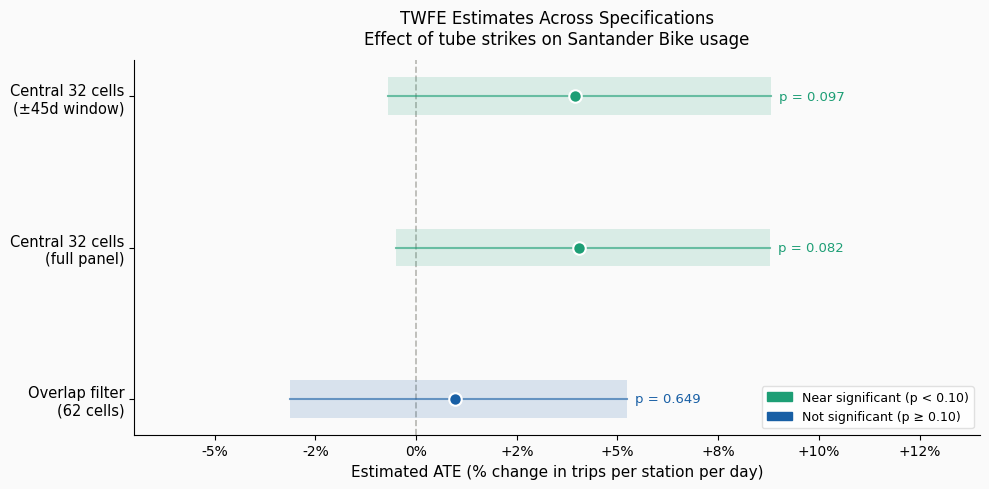

In [11]:

specs   = [
    "Overlap filter\n(62 cells)",
    "Central 32 cells\n(full panel)",
    "Central 32 cells\n(±45d window)",
]
ates    = [ 0.96,  4.04,  3.95]
ci_los  = [-3.13, -0.50, -0.70]
ci_his  = [ 5.23,  8.78,  8.81]
pvals   = [ 0.649,  0.082,  0.097]

colors  = ["#1D9E75" if p < 0.10 else "#185FA5" for p in pvals]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

y_pos = range(len(specs))

for i, (ate, lo, hi, p, c) in enumerate(zip(ates, ci_los, ci_his, pvals, colors)):
    # CI bar
    ax.barh(i, hi - lo, left=lo, height=0.25,
            color=c, alpha=0.15, zorder=2)
    ax.plot([lo, hi], [i, i], color=c, linewidth=1.5,
            alpha=0.6, zorder=3)
    # Point estimate
    ax.plot(ate, i, "o", color=c, markersize=9,
            markeredgecolor="white", markeredgewidth=1.5, zorder=4)
    # p-value annotation
    ax.annotate(f"p = {p:.3f}",
                xy=(hi + 0.2, i), va="center",
                fontsize=9.5, color=c)

ax.axvline(0, color="#888780", linewidth=1.2,
           linestyle="--", alpha=0.6, zorder=1)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(specs, fontsize=10.5)
ax.set_xlabel("Estimated ATE (% change in trips per station per day)", fontsize=11)
ax.set_xlim(-7, 14)
ax.set_title(
    "TWFE Estimates Across Specifications\n"
    "Effect of tube strikes on Santander Bike usage",
    fontsize=12, fontweight="normal", pad=12,
)

legend = [
    mpatches.Patch(color="#1D9E75", label="Near significant (p < 0.10)"),
    mpatches.Patch(color="#185FA5", label="Not significant (p ≥ 0.10)"),
]
ax.legend(handles=legend, fontsize=9, loc="lower right",
          framealpha=0.9, edgecolor="#DDDDDD")

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelsize=10)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"+{x:.0f}%" if x > 0 else f"{x:.0f}%")
)

plt.tight_layout()
plt.savefig("twfe_specifications.png", dpi=180,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()

Parallel Trends Assumption Check

In [18]:
# ── Build cell-level placebo (not date-level — preserves geographic targeting) ──
treated_pairs = (
    local_window.loc[local_window["treated"] == 1, ["h3_cell", "day"]]
    .drop_duplicates()
    .copy()
)
treated_pairs["placebo_date"] = treated_pairs["day"] - pd.Timedelta(days=14)

# Check for overlap between placebo dates and real strike dates
real_dates    = set(treated_pairs["day"].dt.normalize().unique())
placebo_dates = set(treated_pairs["placebo_date"].dt.normalize().unique())
overlap       = real_dates & placebo_dates
print(f"Placebo dates overlapping real strike dates: {len(overlap)}")

placebo_keys = treated_pairs[["h3_cell", "placebo_date"]].rename(
    columns={"placebo_date": "day"}
)
placebo_keys["placebo"] = 1

cell_day_p = local_window.merge(placebo_keys, on=["h3_cell", "day"], how="left")
cell_day_p["placebo"] = cell_day_p["placebo"].fillna(0).astype(int)

# Exclude real strike days + any placebo date that falls on a strike date
near_strike = cell_day_p["day"].dt.normalize().isin(
    set().union(*[{d + pd.Timedelta(days=k) for k in range(-7, 8)} for d in real_dates])
)
placebo_df = cell_day_p[
    (cell_day_p["treated"] == 0) & (~near_strike)
].copy()

placebo_ctrl_vars = [
    "placebo","y_per_station_log1p", "treated", "date_str", "h3_cell",
    "temperature_2m", "precipitation", "is_weekend",
    "is_bank_holiday", "is_school_holiday",
    "days_to_next_strike", "days_since_last_strike", "n_tube_within_500m",
    "dist_nearest_tube_km", 'total_trips', 'n_stations', 'day', 'frac_exposed'
]
placebo_clean = placebo_df[placebo_ctrl_vars].dropna().copy()

twfe_placebo = smf.ols(
    "y_per_station_log1p ~ placebo + C(h3_cell) + C(date_str) + temperature_2m + " 
    "precipitation + is_weekend + is_bank_holiday + is_school_holiday"
    "+ days_to_next_strike + days_since_last_strike",
    data=placebo_clean,
).fit(cov_type="cluster", cov_kwds={"groups": placebo_clean["h3_cell"]})

placebo_ate = np.expm1(twfe_placebo.params["placebo"]) * 100
placebo_pv  = twfe_placebo.pvalues["placebo"]
print(f"\nPlacebo ATE : {placebo_ate:+.2f}%")
print(f"p-value     : {placebo_pv:.4f}")
print("(Should be near 0% and not significant)")
if placebo_pv > 0.05:
    print("✓ Placebo not significant — parallel trends supported")
else:
    print("✗ Placebo significant — investigate anticipation effects")

Placebo dates overlapping real strike dates: 1

Placebo ATE : -2.27%
p-value     : 0.2773
(Should be near 0% and not significant)
✓ Placebo not significant — parallel trends supported
